In [1]:
import os
import yaml
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.utils import shuffle

from helpers.likelihood_visualizers import make_c_grid, c_scan_1d
from helpers.test_statistics import get_test_statistic_rate_at_c_points, get_N_sig_obs_at_c_point
from helpers.network_training import NeuralNet

torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
run_id = "top3_all"

# scan_index:
# 0 = cp / cphi
# 1 = cdp / cphid
# 2 = ctp / ctphi
scan_index = 0
scan_label = r"$c_\phi$"

with open("workflow.yaml", "r") as file:
    workflow = yaml.safe_load(file)

with open(f"run_configs/{run_id}.yml", "r") as file:
    run_configs = yaml.safe_load(file)

samples_dir = workflow["sampling"]["output_dir"]
identity_code = run_configs["input_precode"]
features = run_configs["features"]
n_features = len(features)
parameter_code = run_configs["parameter_code"]
network_id = run_configs["network_id"]

print("samples_dir =", samples_dir)
print("identity_code =", identity_code)
print("parameter_code =", parameter_code)
print("features =", features)
print("n_features =", n_features)
print("network_id =", network_id)

samples_dir = /vols/cms/jl3222/nsbi_photon_final_state/05_samples
identity_code = delphes_s
parameter_code = c2
features = [24, 21, 22]
n_features = 3
network_id = top3_all


In [3]:
signal_dir = f"{samples_dir}/plain_real/{identity_code}/{parameter_code}"
bkg_dir = f"{samples_dir}/plain_real/delphes_b0/{parameter_code}"

test_sets = {}

test_sets["sm"] = shuffle(
    np.load(f"{signal_dir}/x_sm_test.npy")[:, features],
    random_state=7
)

test_sets["bkg"] = shuffle(
    np.load(f"{bkg_dir}/x_bkg_test.npy")[:, features],
    random_state=7
)

print("SM test shape:", test_sets["sm"].shape)
print("BKG test shape:", test_sets["bkg"].shape)

SM test shape: (1000000, 3)
BKG test shape: (10000, 3)


In [4]:
with open(f"models/scaler_{network_id}.pkl", "rb") as ifile:
    scaler = pickle.load(ifile)

for key in test_sets:
    test_sets[key] = scaler.transform(test_sets[key])

print("Scaling done.")

Scaling done.


In [5]:
seeds = [0]

dense_nets_eval_seeds = {
    0: {
        "Ssm_Salt": NeuralNet(n_inputs=n_features + 3, layers=run_configs["network.layers"]),
        "B_Salt": NeuralNet(n_inputs=n_features + 3, layers=run_configs["network.layers"]),
        "Ssm_B": NeuralNet(n_inputs=n_features, layers=run_configs["network.layers"]),
    }
}

for key in dense_nets_eval_seeds[0]:
    model_path = f"models/{network_id}_{key}_best_model.pt"
    print("Loading:", model_path)

    checkpoint = torch.load(model_path, map_location=device)
    dense_nets_eval_seeds[0][key].load_state_dict(checkpoint["model_state_dict"])
    dense_nets_eval_seeds[0][key].eval().to(device)

print("All networks loaded.")

Loading: models/top3_all_Ssm_Salt_best_model.pt
Loading: models/top3_all_B_Salt_best_model.pt
Loading: models/top3_all_Ssm_B_best_model.pt
All networks loaded.


/tmp/ipykernel_3535868/3276922015.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


In [7]:
N_sig_SM_target = 3600
N_bkg_SM_target = 8160

data_input_dir = "/vols/cms/jl3222/nsbi_backups/combined_samples"

loc_c_point = (0, 0, 0)

loc_N_sig_obs = get_N_sig_obs_at_c_point(
    data_input_dir,
    identity_code,
    loc_c_point,
    N_sig_SM_target
)

print("Expected signal events at SM:", loc_N_sig_obs)

loc_test_set_sig = test_sets["sm"][:int(loc_N_sig_obs)]
loc_test_set_bkg = test_sets["bkg"][:int(N_bkg_SM_target)]

if loc_test_set_sig.shape[0] < int(loc_N_sig_obs):
    print("CAUTION: not enough SM signal test events.")

if loc_test_set_bkg.shape[0] < int(N_bkg_SM_target):
    print("CAUTION: not enough background test events.")

loc_test_set = np.vstack([loc_test_set_sig, loc_test_set_bkg])

print("Pseudo-data shape:", loc_test_set.shape)

Expected signal events at SM: 3600.0
Pseudo-data shape: (11760, 3)


In [10]:
lower_limits = [-1.4, -0.45, -0.6]
upper_limits = [0.4, 0.55, 0.5]

c_grid, c_scans, edges = make_c_grid(
    101,
    lower_limits,
    upper_limits,
    str(scan_index)
)

print("Scan variable:", scan_label)
print("c_grid shape:", c_grid.shape)
print("c_scans type:", type(c_scans))
print("c_scans keys:", c_scans.keys())

scan_key = scan_index
print("scan range:", c_scans[scan_key][0], "to", c_scans[scan_key][-1])
print("scan length:", len(c_scans[scan_key]))

Scan variable: $c_\phi$
c_grid shape: (101, 3)
c_scans type: <class 'dict'>
c_scans keys: dict_keys([0, 1, 2])
scan range: -1.4 to 0.4
scan length: 101


In [11]:
loc_q_rate, N_sig_c_scan = get_test_statistic_rate_at_c_points(
    data_input_dir,
    identity_code,
    10 * c_grid,
    N_sig_SM_target,
    N_bkg_SM_target,
    N_bkg_SM_target + loc_N_sig_obs
)

print("Rate-only calculation done.")
print("loc_q_rate shape:", loc_q_rate.shape)
print("N_sig_c_scan shape:", N_sig_c_scan.shape)

Rate-only calculation done.
loc_q_rate shape: (101,)
N_sig_c_scan shape: (101,)


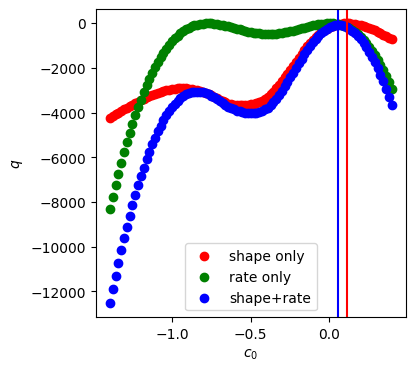

Rate + top3 shape calculation done.
loc_q_all shape: (101,)


In [15]:
loc_q_all = c_scan_1d(
    dense_nets_eval_seeds,
    device,
    loc_test_set,
    N_sig_c_scan,
    N_sig_SM_target,
    N_bkg_SM_target,
    c_grid,
    c_scans,
    str(scan_index),
    seeds,
    q_rate=loc_q_rate
)

print("Rate + top3 shape calculation done.")
print("loc_q_all shape:", loc_q_all.shape)